In [1]:
# Import all the needed packages
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import cho_factor, cho_solve
import torch
import spyrit.core.torch as st

**Comparison of Three Methods in Distributed Sketching for Randomized Optimization**<br>
*Uniform Sampling (Without padding or With padding)*<br>
*Hadamard Randomized Sampling*<br>
*Subsampled Randomized Hadamard Transforom*<br>

**Step 1: Simulation**

In [2]:
def simulate_matrix(n, d, no_components,rho,abs_bound_X):
    ###Form the X matrix
    X = np.zeros((0, d))
    # Divide the levels of MVG into different components according to the desired number =<5
    def generate_components(n, no_components):
        if no_components == 2:
            component = [int(n*0.95), int(n*0.05)]
        elif no_components == 3:
            component = [int(n*0.85), int(n*0.10), int(n*0.05)]
        elif no_components == 4:
            component = [int(n*0.70), int(n*0.15), int(n*0.10), int(n*0.05)]
        elif no_components == 5:
            component = [int(n*0.50), int(n*0.20), int(n*0.15), int(n*0.10), int(n*0.05)]
        else:
            raise ValueError("Invalid number of components")
        # adjust the last component to ensure the sum is exactly n
        component[-1] = n - sum(component[:-1])
        # mean_list = range(1,no_components+1)
        mean = []
        for i in range(no_components):
            if i == 0:
                mean.append(1)
            else:
                mean.append(10+i)
        mean = np.array(mean)
        return component,mean
    # Generate these multivariate gaussian components in different levels of mean and cov.
    num_list,mean_list= generate_components(n, no_components)
    for i in range(no_components):
        # each level's mean value.
        mean_value = mean_list[i]
        # 0.8 probability of 1 and 0.2 probability of 0 for creating a sparse mean vector.
        mean_vector = np.random.binomial(1, 0.9, size = d)
        mean = mean_value * mean_vector
        # randomly generate a symmetric cov matrix and entity from 0.5 to 1.
        def generate_symmetric_matrix(n):
            S = np.zeros((n, n))
            upper_triangle_indices = np.triu_indices(n)
            random_numbers = np.random.uniform(0.5, 1, len(upper_triangle_indices[0]))
            S[upper_triangle_indices] = random_numbers
            S += S.T
            S[np.diag_indices(n)] /= 2
            return S
        cov = generate_symmetric_matrix(d)
        # generate a component of X.
        X_ = np.random.multivariate_normal(mean, cov, num_list[i])
        X_ = np.array(X_)
        # append the component to the list.
        X = np.vstack((X, X_))
    X = np.array(X)
    # Set the elements < 3 to 0 to make it a sparse matrix
    X[abs(X) < abs_bound_X] = 0
    ###Form the fixed beta
    beta_value = np.random.binomial(1, 0.9, size = d)
    beta = (beta_value * np.random.uniform(-1, 1, size = d)).reshape(-1,1)
    beta = np.array(beta)
    ###Form the error term - epsilon, which has the auto-correlation structure in time series analysis.
    r = rho # autocorrelation coefficient
    epsilon_matrix = np.zeros((0,1)) # define a zero initial matrix for vstack
    ###Form the error term in the same levels
    for i in range(no_components):
        epsilon = np.zeros((num_list[i],1))
        epsilon[0] = np.random.normal(0,1)
        for t in range(1,num_list[i]):
            epsilon[t] = r * epsilon[t-1] + np.random.normal(0,1)
        epsilon = np.array(epsilon)
        epsilon_matrix = np.vstack((epsilon_matrix, epsilon))
    epsilon_matrix = np.array(epsilon_matrix)
    epsilon = epsilon_matrix
    ###Form the Y matrix
    Y = np.array(X @ beta + epsilon)
    return X,Y,beta,epsilon

In [3]:
# Matrix Settled
n = 5000                           # number of rows
d = 200                            # number of columns     
no_components = 3                  # number of levels of multivariate gaussian distribution in X
rho = 0.8                          # autocorrelation coefficient in time series analysis
abs_bound_X = 0.5                  # absolute bound for X to set elements to be 0
X,Y,beta,epsilon= simulate_matrix(n, d, no_components,rho,abs_bound_X)

C:\Users\yishu\AppData\Local\Temp\ipykernel_6700\187701895.py:46: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X_ = np.random.multivariate_normal(mean, cov, num_list[i])


**Step 2: Singular Value Decomposition (SVD)**<br>
*To show the sparsity and not even distribution*

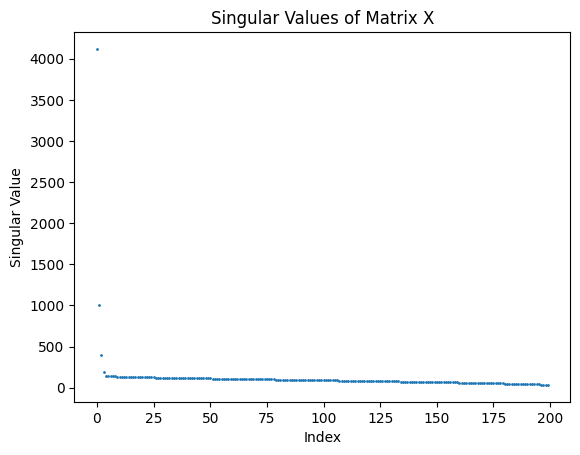

In [4]:
# Compute singular values
U, s, Vh = np.linalg.svd(X)

# Sort singular values in descending order
# s_sorted = np.sort(s)[::-1]

# Plot singular values using a dot plot
plt.scatter(range(len(s)), s,s = 1)
plt.xlabel('Index')
plt.ylabel('Singular Value')
plt.title('Singular Values of Matrix X')
plt.show()

**Step 3: Padding**<br>
*To fit for hadamard randomized sketching*

In [5]:
# Padding to fit for hadamard randomized sketching
def padding(X, y):
    m = X.shape[0]
    if np.ceil(np.log2(m)) > np.log2(m):
        m1 = int(np.floor(np.log2(m))) + 1
        padX = np.vstack((X, np.zeros((2**m1 - m, X.shape[1]))))
        pady = np.append(y, np.zeros(2**m1 - m))
    else:
        padX = X
        pady = y
    return padX, pady
###Padding X and Y for preparation of hadamard randomized sketching.
X_pad,Y_pad = padding(X,Y)

**Step 4: Define functions for calculating error ratio and norms**

In [6]:
def calculate_the_norm_square(A, b, x_selected):
    A = np.array(A)
    x_selected = np.array(x_selected)
    return np.sum((np.dot(A, x_selected) - b) ** 2)
def error_ratio(A,b,x_hat_bar,x_star):
    return (calculate_the_norm_square(A,b,x_hat_bar) - calculate_the_norm_square(A,b,x_star)) / calculate_the_norm_square(A,b,x_star)

**Step 5: Solve for X_star**<br>
*Use cholesky decomposition for solving X_star*

In [7]:
def solver(A,b):
    A = np.array(A)
    b = np.array(b)
    # cholesky decomposition algorithm
    L,low = cho_factor(A.T@A)
    x_star = cho_solve((L,low),A.T@b)
    return x_star
x_star_no_padding = solver(X,Y)
x_star_padding = solver(X_pad,Y_pad)
# Calculate the norm difference using Euclidean norm (L2 norm)
norm_difference = np.linalg.norm(x_star_no_padding - x_star_padding)
print("The norm difference between x_star_no_padding and x_star_padding is:")
print(norm_difference)

The norm difference between x_star_no_padding and x_star_padding is:
143.4427079528376


**STEP 6: Uniform Sampling Sampling // Algorithm 1: Distributed Randomized Regression**

In [8]:
# e.g. our desired sketching size is m = 1000
m = 1000
# Algorithm 1 inserting inside uniform sampling: Distributed Randomized Regression

# S_k @ A here is just computed as A [uniformly_sampled_index]
# As S_k here is just a diagnoal matrix of 1 or 0 where sampled rows have 1 as value
def uniform_sampling_1(X,Y,n,m,q):
    X = np.array(X)
    Y = np.array(Y)
    x_hat_list = []
    for k in range(q):
        index = np.random.choice(n, size=m, replace=False)
        X_sk = X[index]
        Y_sk = Y[index]
        x_hat = solver(X_sk,Y_sk)
        x_hat_list.append(x_hat)
    x_bar = sum(x_hat_list) / q
    return x_bar

**Step 7: Hadamard Randomized Sampling // Algorithm 1: Distributed Randomized Regression**<br>

In [9]:
# Algorithm 1 inserting inside hadamard rademacher randomization: Distributed Randomized Regression

# Step 1: Hadamard rademacher randomization
def fhm(X,Y):
    # Generate a diagonal matrix of -1 or 1 with 0.5 probability
    diag_matrix = np.diag(np.random.choice([-1, 1], size=X.shape[0]))
    signs = diag_matrix
    # Multiply each row of X and Y by the corresponding sign
    result_X = np.dot(signs, X)
    result_Y = np.dot(signs, Y)
    # Convert to PyTorch tensor with float64
    tensor_matrix_X = torch.tensor(result_X, dtype=torch.float64)
    tensor_matrix_Y = torch.tensor(result_Y, dtype=torch.float64)
    # Apply FWHT
    tensor_matrix_X = st.fwht(tensor_matrix_X.T).T
    tensor_matrix_Y = st.fwht(tensor_matrix_Y)
    # Convert back to numpy array
    X = tensor_matrix_X.numpy()
    Y = tensor_matrix_Y.numpy()
    return X, Y

In [10]:
# Step 2: Uniform sampling on the Hadamard transformed X
def Hadamard_Randomized_Sampling_1(X, Y, n, m, q):
    X = np.array(X)
    Y = np.array(Y)
    X, Y = fhm(X, Y)
    x_hat_list = []
    for k in range(q):
        index = np.random.choice(n, size=m, replace=False)
        X_sk = X[index] / np.sqrt(m)
        Y_sk = Y[index] / np.sqrt(m)
        X_sk = np.array(X_sk)
        Y_sk = np.array(Y_sk)
        x_hat = solver(X_sk,Y_sk)
        x_hat_list.append(x_hat)
    x_bar = sum(x_hat_list) / q
    return x_bar

**Step 8: Subsampled Randomized Hadamard Transforom // Algorithm 1: Distributed Randomized Regression**<br>

In [ ]:
def Subsampled_Randomized_Hadamard_Transform_1(X, Y, n, m, q):
    # Convert inputs to numpy arrays
    X = np.array(X)
    Y = np.array(Y)
    
    # Store copies of the original X and Y
    X_orig = X.copy()
    Y_orig = Y.copy()
    
    x_hat_list = []
    for k in range(q):
        # Apply fhm to the original X and Y, not the transformed versions
        X_transformed, Y_transformed = fhm(X_orig, Y_orig)
        
        # Subsample m rows from the transformed matrices
        index = np.random.choice(n, size=m, replace=False)
        X_sk = X_transformed[index] / np.sqrt(m)
        Y_sk = Y_transformed[index] / np.sqrt(m)
        
        # Ensure subsampled matrices are numpy arrays
        X_sk = np.array(X_sk)
        Y_sk = np.array(Y_sk)
        
        # Solve the smaller problem
        x_hat = solver(X_sk, Y_sk)
        x_hat_list.append(x_hat)
    
    # Average the solutions
    x_bar = sum(x_hat_list) / q
    return x_bar

**Step 9: Final Error Ratio plot for comparison of these three methods**<br>
*Note that in the Uniform Sampling there is two version: With padding or Without padding of matrices X and Y*<br>

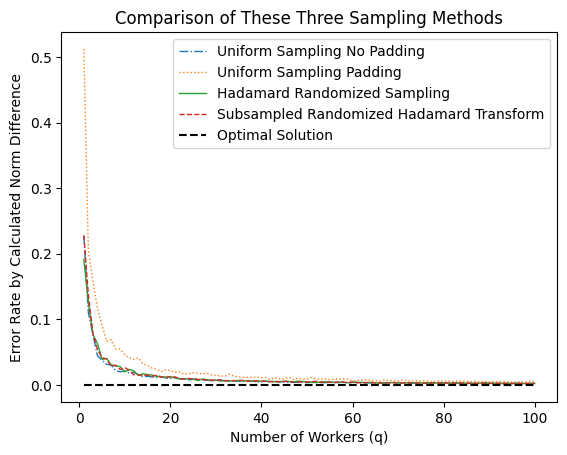

In [12]:
error_uniform_no_padding = []
error_uniform_padding = []
error_hadamard_rand = []
error_SRHT = []
error_star = np.zeros((100,1))

# Calculate the error rate for each method
for q in range(1, 101):  # adjust the range as needed
    x_bar_uniform_no_padding = uniform_sampling_1(X,Y,X.shape[0],m,q)
    x_bar_uniform_padding = uniform_sampling_1(X_pad,Y_pad,X_pad.shape[0],m,q)
    x_bar_hadamard_rand = Hadamard_Randomized_Sampling_1(X_pad,Y_pad,X_pad.shape[0],m,q)
    x_bar_SRHT = Subsampled_Randomized_Hadamard_Transform_1(X_pad,Y_pad,X_pad.shape[0],m,q)
    error_uniform_no_padding.append(error_ratio(X,Y,x_bar_uniform_no_padding,x_star_no_padding))
    error_uniform_padding.append(error_ratio(X_pad,Y_pad,x_bar_uniform_padding,x_star_padding))
    error_hadamard_rand.append(error_ratio(X_pad,Y_pad,x_bar_hadamard_rand,x_star_padding))
    error_SRHT.append(error_ratio(X_pad,Y_pad,x_bar_SRHT,x_star_padding))

# Create the plot
plt.plot(range(1, 101), error_uniform_no_padding, label='Uniform Sampling No Padding',linestyle = '-.',linewidth = 1)
plt.plot(range(1, 101),error_uniform_padding,label='Uniform Sampling Padding',linestyle = ':',linewidth = 1)
plt.plot(range(1, 101), error_hadamard_rand, label='Hadamard Randomized Sampling',linestyle = '-',linewidth = 1)
plt.plot(range(1, 101), error_SRHT, label='Subsampled Randomized Hadamard Transform',linestyle = '--',linewidth = 1)
plt.plot(range(1, 101), error_star, label='Optimal Solution', linestyle='--',color = 'black')

# Add labels and title
plt.xlabel('Number of Workers (q)')
plt.ylabel('Error Rate by Calculated Norm Difference')
plt.title('Comparison of These Three Sampling Methods')
plt.legend()
plt.show()